你可以在[这篇博客文章](http://www.fast.ai/2017/07/17/num-lin-alg/)中阅读本“数值线性代数（Numerical Linear Algebra）”课程的概览。本课程最初在[旧金山大学（University of San Francisco）分析学硕士项目（MS in Analytics）](https://www.usfca.edu/arts-sciences/graduate-programs/analytics)中开设。课程讲座视频[已发布到 YouTube](https://www.youtube.com/playlist?list=PLtmWHNX-gukIc92m1K0P6bIOnZb-mg0hY)（注意：notebook 的编号与视频编号并不一致，因为有些 notebook 需要不止 1 个视频才能覆盖）。

你可以在我们的 fast.ai 论坛（fast.ai forums）上就本课程提问：[论坛链接](http://forums.fast.ai/c/lin-alg)。

# 3. 使用鲁棒主成分分析（Robust PCA）进行背景去除（Background Removal）

**我们今天的目标（goal）**：![background removal](images/surveillance3.png)

## 开始（Getting Started）

我们使用来自 [BMC 2012 背景建模挑战数据集（Background Models Challenge Dataset）](http://bmc.iut-auvergne.com/?page_id=24) 的真实视频 003 数据集。

其他数据集来源：
- [人体活动视频数据集（Human Activity Video Datasets）](https://www.cs.utexas.edu/~chaoyeh/web_action_data/dataset_list.html)
- [背景减除网站（Background Subtraction Website）](https://sites.google.com/site/backgroundsubtraction/test-sequences)（该网站上有少量链接已失效/过期，但仍有很多可用）

导入所需的库（libraries）：

In [5]:
from moviepy import VideoFileClip
# from IPython.display import display
from glob import glob

In [ ]:
import sys, os
import numpy as np
import scipy

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
# MAX_ITERS = 10
TOL = 1.0e-8

In [6]:
video = VideoFileClip("data/Video_003.avi")

FileNotFoundError: 'data/Video_003.avi' not found

In [ ]:
video.subclip(0,50).ipython_display(width=600)

NameError: name 'video' is not defined

In [36]:
video.duration

113.57

### 辅助方法（Helper Methods）

In [37]:
def create_data_matrix_from_video(clip, k=5, scale=50):
 return np.vstack([scipy.misc.imresize(rgb2gray(clip.get_frame(i/float(k))).astype(int), 
 scale).flatten() for i in range(k * int(clip.duration))]).T

In [38]:
def rgb2gray(rgb):
 return np.dot(rgb[...,:3], [0.299, 0.587, 0.114])

In [83]:
def plt_images(M, A, E, index_array, dims, filename=None):
 f = plt.figure(figsize=(15, 10))
 r = len(index_array)
 pics = r * 3
 for k, i in enumerate(index_array):
 for j, mat in enumerate([M, A, E]):
 sp = f.add_subplot(r, 3, 3*k + j + 1)
 sp.axis('Off')
 pixels = mat[:,i]
 if isinstance(pixels, scipy.sparse.csr_matrix):
 pixels = pixels.todense()
 plt.imshow(np.reshape(pixels, dims), cmap='gray')
 return f

In [95]:
def plots(ims, dims, figsize=(15,20), rows=1, interp=False, titles=None):
 if type(ims[0]) is np.ndarray:
 ims = np.array(ims)
 f = plt.figure(figsize=figsize)
 for i in range(len(ims)):
 sp = f.add_subplot(rows, len(ims)//rows, i+1)
 sp.axis('Off')
 plt.imshow(np.reshape(ims[i], dims), cmap="gray")

### 加载并查看数据（Load and view the data）

在某一时刻的一帧图像（缩放后）大小是 60 像素 × 80 像素。我们可以把这张图 *展开（unroll）* 成一个很长的列向量。因此，与其说我们有一张 $60 \times 80$ 的二维图片，不如说我们有一个 $1 \times 4,800$ 的列向量。

这对人类阅读并不友好，但它很方便：因为这样我们就能把不同时间点的图像按时间顺序堆叠起来，把整个视频放进一个矩阵里。比如，如果我们对一段 113 秒的视频每 0.1 秒取一帧（因此有 11,300 张不同的图像，每一张来自不同时间点），那么我们就会得到一个 $11300 \times 4800$ 的矩阵，用来表示这段视频！

In [40]:
scale = 25 # Adjust scale to change resolution of image
dims = (int(240 * (scale/100)), int(320 * (scale/100)))

In [41]:
M = create_data_matrix_from_video(video, 100, scale)
# M = np.load("high_res_surveillance_matrix.npy")

In [13]:
print(dims, M.shape)

(60, 80) (4800, 11300)


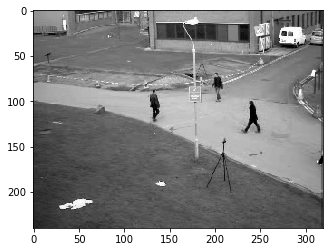

In [79]:
plt.imshow(np.reshape(M[:,140], dims), cmap='gray');

由于 `create_data_from_matrix` 运行有些慢，我们会把矩阵保存下来。一般来说，只要你的预处理（pre-processing）步骤比较慢，就很值得把结果保存起来，方便以后复用。

In [42]:
np.save("low_res_surveillance_matrix.npy", M)

注意（Note）：高分辨率（high-res）的 $M$ 太大，无法直接绘图；所以下面这段只在低分辨率（low-res）版本上运行。

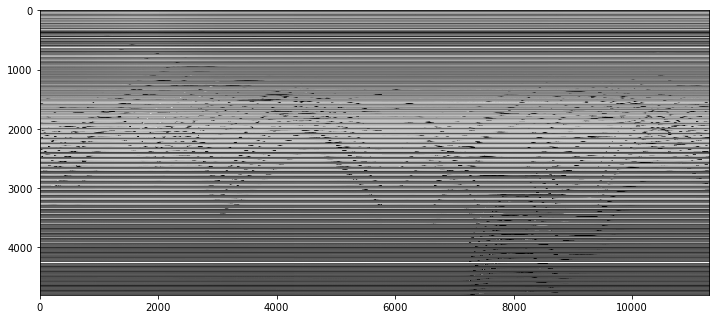

In [33]:
plt.figure(figsize=(12, 12))
plt.imshow(M, cmap='gray')

**思考题（Questions）**：那些波浪状的黑线是什么？水平的线又是什么？

In [ ]:
plt.imsave(fname="image1.jpg", arr=np.reshape(M[:,140], dims), cmap='gray')

## 奇异值分解（SVD）

**第 2 课复习（Review from Lesson 2）**：
- SVD 会返回什么类型/形状的矩阵？
- 有什么办法可以加速截断 SVD（truncated SVD）？

### 用 SVD 的第一次尝试（A first attempt with SVD）

In [43]:
from sklearn import decomposition

In [44]:
u, s, v = decomposition.randomized_svd(M, 2)

In [45]:
u.shape, s.shape, v.shape

((4800, 2), (2,), (2, 11300))

In [46]:
low_rank = u @ np.diag(s) @ v

In [47]:
low_rank.shape

(4800, 11300)

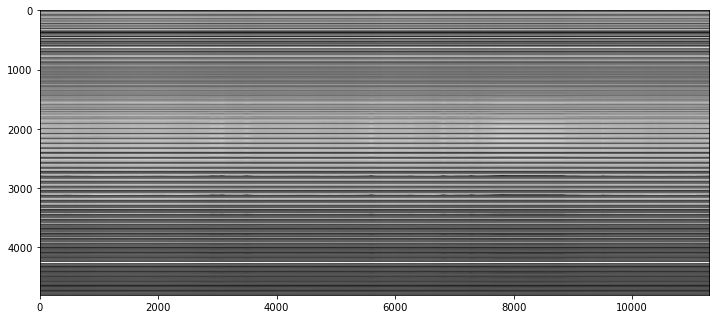

In [19]:
plt.figure(figsize=(12, 12))
plt.imshow(low_rank, cmap='gray')

下面这些图像使用高分辨率（high-res）数据生成，处理会非常慢：

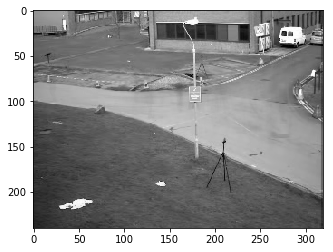

In [18]:
plt.imshow(np.reshape(low_rank[:,140], dims), cmap='gray');

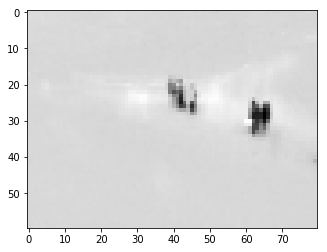

In [21]:
plt.imshow(np.reshape(M[:,550] - low_rank[:,550], dims), cmap='gray');

#### 秩 1 近似（Rank-1 Approximation）

In [22]:
u, s, v = decomposition.randomized_svd(M, 1)

In [23]:
u.shape, s.shape, v.shape

((4800, 1), (1,), (1, 11300))

In [24]:
low_rank = u @ np.diag(s) @ v

In [25]:
low_rank.shape

(4800, 11300)

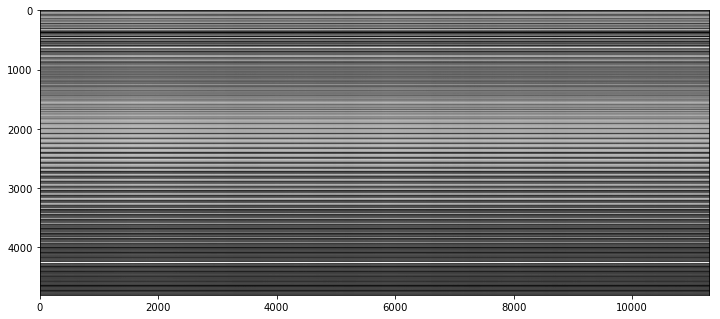

In [26]:
plt.figure(figsize=(12, 12))
plt.imshow(low_rank, cmap='gray')

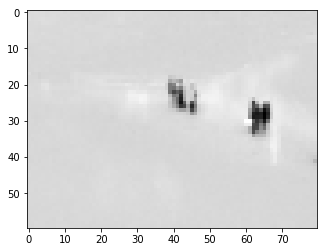

In [27]:
plt.imshow(np.reshape(M[:,550] - low_rank[:,550], dims), cmap='gray');

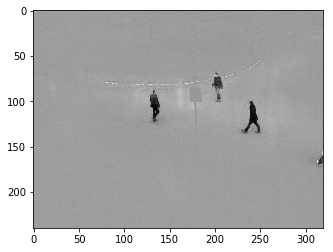

In [35]:
plt.imshow(np.reshape(M[:,140] - low_rank[:,140], dims), cmap='gray');

让我们把人放大看清楚：

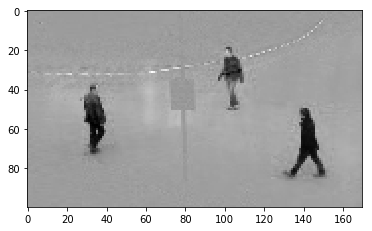

In [36]:
plt.imshow(np.reshape(M[:,140] - low_rank[:,140], dims)[50:150,100:270], cmap='gray');

这个方法这么简单却效果惊人！下面我们会用一个更复杂的算法得到一些更好的结果。

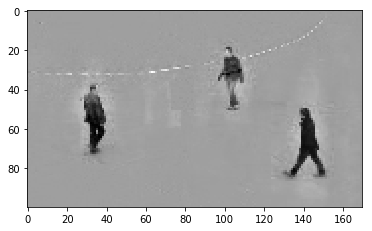

In [33]:
plt.imshow(np.reshape(S[:,140], dims)[50:150,100:270], cmap='gray')

## 主成分分析（Principal Component Analysis, PCA）

在处理高维数据集时，我们常常利用这样一个事实：数据具有**较低的内在维度（low intrinsic dimensionality）**，从而缓解“维数灾难（curse of dimensionality）”并更容易扩展规模（例如数据可能位于某个低维子空间（low-dimensional subspace）中，或位于低维流形（low-dimensional manifold）上）。[主成分分析（principal component analysis）](http://setosa.io/ev/principal-component-analysis/) 很适合用来消除维度。经典的 PCA 寻找矩阵 $M$ 的最佳秩-$k$ 近似 $L$（最小化 $\| M - L \|$，其中 $L$ 的秩为 $k$）。截断奇异值分解（Truncated SVD）可以完成这个计算！

传统 PCA 可以处理小幅噪声，但对于严重污染（grossly corrupted）的观测非常脆弱——哪怕只有一个严重污染的观测，也可能显著破坏结果。

**鲁棒 PCA（Robust PCA）** 将矩阵分解为两个矩阵之和：$M = L + S$，其中 $M$ 是原始矩阵，$L$ 是**低秩（low-rank）**的，$S$ 是**稀疏（sparse）**的。这正是我们要用来做背景去除（background removal）的问题！**低秩**表示矩阵中存在大量冗余信息——在这里就是背景，因为每一帧场景中的背景基本相同（这就是“冗余信息”的典型例子）。**稀疏**表示矩阵的大部分元素为 0——在这里可以理解为前景（foreground，行人）的图像在整幅画面中占比很小、很多区域接近空白。（在数据被污染（corrupted data）的情形下，$S$ 会捕捉那些被污染的条目。）

### 鲁棒 PCA（Robust PCA）的应用（Applications）
- **视频监控（Video Surveillance）**

- **人脸识别（Face Recognition）**：图片来自这个很棒的[教程（tutorial）](https://jeankossaifi.github.io/tensorly/rpca.html)。这里的数据集由多个人的人脸图像组成：拍摄角度相同，但光照（illumination）不同。

  <img src="images/faces_rpca.png" alt="Robust PCA" style="width: 80%"/>
  （[来源（Source）：Jean Kossaifi](https://jeankossaifi.github.io/tensorly/rpca.html)）

  <img src="images/faces_rpca_gross.png" alt="Robust PCA" style="width: 80%"/>
  （[来源（Source）：Jean Kossaifi](https://jeankossaifi.github.io/tensorly/rpca.html)）

- 潜在语义索引（Latent Semantic Indexing）：$L$ 捕捉所有文档中共同出现的常用词，而 $S$ 捕捉那少量最能区分不同文档的关键词

- 排名与协同过滤（Ranking and Collaborative Filtering）：可用的少量排名数据可能带噪声，甚至可能被篡改（可参考 Netflix 官方博客的 [Netflix RAD - Outlier Detection on Big Data](http://techblog.netflix.com/2015/02/rad-outlier-detection-on-big-data.html)）

### L1 范数诱导稀疏性（L1 norm induces sparsity）

在 L1 范数下，单位球 $\lVert x \rVert_1 = 1$ 是一个菱形。它的极值点（extrema）在各个角上：

 <img src="images/L1vsL2.jpg" alt="L1 norm" style="width: 60%"/>
  （[来源（Source）](https://www.quora.com/Why-is-L1-regularization-supposed-to-lead-to-sparsity-than-L2)）
  
  另一个类似的视角是观察损失函数（loss function）的 *等高线（contours）*：
 <img src="images/L1vsL2_2.png" alt="L2 norm" style="width: 60%"/>
  （[来源（Source）](https://www.quora.com/Why-is-L1-regularization-better-than-L2-regularization-provided-that-all-Norms-are-equivalent)）

### 优化问题（Optimization Problem）

鲁棒 PCA（Robust PCA）可以写成：

$$ minimize\; \lVert L \rVert_* + \lambda\lVert S \rVert_1 \\ subject\;to\; L + S = M$$
 
其中：

- $\lVert \cdot \rVert_1$ 是 **L1 范数（L1 norm）**。最小化 [L1 范数（L1 norm）](https://medium.com/@shiyan/l1-norm-regularization-and-sparsity-explained-for-dummies-5b0e4be3938a) 会得到稀疏（sparse）的解。对于矩阵而言，L1 诱导的矩阵范数等于[最大绝对列和范数（maximum absolute column norm）](https://math.stackexchange.com/questions/519279/why-is-the-matrix-norm-a-1-maximum-absolute-column-sum-of-the-matrix)。

- $ \lVert \cdot \rVert_* $ 是 **核范数（nuclear norm）**，也就是奇异值（singular values）的 L1 范数。尝试最小化它会让奇异值变得稀疏（sparse singular values）从而得到低秩（low rank）。


### 从论文实现算法（Implementing an algorithm from a paper）

#### 来源（Source）
我们将使用这篇[鲁棒 PCA 论文（Robust PCA paper）](https://arxiv.org/pdf/0912.3599.pdf)（Candes, Li, Ma, Wright）中的通用**主成分追踪（principal component pursuit, PCP）算法**；具体采用论文[《Matrix Completion via the Inexact ALM Method》](https://arxiv.org/pdf/1009.5055.pdf)（Lin, Chen, Ma）中第 3.1 节给出的形式。我也参考了这里的实现：[robust_pcp.py](https://github.com/shriphani/robust_pcp/blob/master/robust_pcp.py) 和 [pcp.py](https://github.com/dfm/pcp/blob/master/pcp.py)。

#### 值得读的部分（The Good Parts）

Candes, Li, Ma, Wright 的论文第 1 节写得很好，第 5 节 Algorithms（算法）是我们最关心的部分。**要从论文实现一个算法，你不必掌握全部数学细节或理解证明。** 但你需要不断尝试不同做法，并在各种资料中“淘”到有用的小细节。这个领域里理论研究者更多，而务实的工程建议相对少。我当初花了好几个月才找到需要的东西并让它跑起来。

算法出现在第 29 页：

 <img src="images/pcp_algorithm.png" alt="PCP algorithm" style="width: 100%"/>

其中需要用到 $\mathcal{S}$（收缩算子，Shrinkage operator）以及 $\mathcal{D}$（奇异值阈值化算子，singular value thresholding operator）的定义：

 <img src="images/candes.png" alt="PCP algorithm" style="width: 100%"/>

[Chen, Lin, Ma]() 的第 3.1 节给出了一个更快的变体（variation）：

 <img src="images/rpca_inexact.png" alt="Inexact RPCA" style="width: 80%"/>

另外，第 4 节提供了一些非常有用的实现细节，比如需要计算多少个奇异值（singular values），以及如何选择参数：

 <img src="images/svp_value.png" alt="SVP values" style="width:70%"/> 

### 如果你想进一步学习理论（theory）：

- Stephen Boyd（斯坦福教授，Stanford Prof）的《凸优化（Convex Optimization）》：
  - [OpenEdX 视频（OpenEdX Videos）](https://www.youtube.com/playlist?list=PLbBM_dvjud8oFj09MqqYnGSrT6zek42Q0)
  - [Jupyter Notebooks](http://web.stanford.edu/~boyd/papers/cvx_short_course.html)
- 乘子交替方向法（Alternating Direction Method of Multipliers, ADMM）（更多内容见 [Stephen Boyd 的页面](http://stanford.edu/~boyd/admm.html)）

## 鲁棒 PCA（Robust PCA，基于主成分追踪：Primary Component Pursuit）

### 方法（Methods）

我们将使用 Facebook 的快速随机化 PCA（Fast Randomized PCA）库：[fbpca](https://github.com/facebook/fbpca)。

In [48]:
from scipy import sparse
from sklearn.utils.extmath import randomized_svd
import fbpca

In [49]:
TOL=1e-9
MAX_ITERS=3

In [50]:
def converged(Z, d_norm):
 err = np.linalg.norm(Z, 'fro') / d_norm
 print('error: ', err)
 return err < TOL

In [51]:
def shrink(M, tau):
 S = np.abs(M) - tau
 return np.sign(M) * np.where(S>0, S, 0)

In [52]:
def _svd(M, rank): return fbpca.pca(M, k=min(rank, np.min(M.shape)), raw=True)

In [53]:
def norm_op(M): return _svd(M, 1)[1][0]

In [54]:
def svd_reconstruct(M, rank, min_sv):
 u, s, v = _svd(M, rank)
 s -= min_sv
 nnz = (s > 0).sum()
 return u[:,:nnz] @ np.diag(s[:nnz]) @ v[:nnz], nnz

In [97]:
def pcp(X, maxiter=10, k=10): # refactored
 m, n = X.shape
 trans = m<n
 if trans: X = X.T; m, n = X.shape
 
 lamda = 1/np.sqrt(m)
 op_norm = norm_op(X)
 Y = np.copy(X) / max(op_norm, np.linalg.norm( X, np.inf) / lamda)
 mu = k*1.25/op_norm; mu_bar = mu * 1e7; rho = k * 1.5
 
 d_norm = np.linalg.norm(X, 'fro')
 L = np.zeros_like(X); sv = 1
 
 examples = []
 
 for i in range(maxiter):
 print("rank sv:", sv)
 X2 = X + Y/mu
 
 # update estimate of Sparse Matrix by "shrinking/truncating": original - low-rank
 S = shrink(X2 - L, lamda/mu)
 
 # update estimate of Low-rank Matrix by doing truncated SVD of rank sv & reconstructing.
 # count of singular values > 1/mu is returned as svp
 L, svp = svd_reconstruct(X2 - S, sv, 1/mu)
 
 # If svp < sv, you are already calculating enough singular values.
 # If not, add 20% (in this case 240) to sv
 sv = svp + (1 if svp < sv else round(0.05*n))
 
 # residual
 Z = X - L - S
 Y += mu*Z; mu *= rho
 
 examples.extend([S[140,:], L[140,:]])
 
 if m > mu_bar: m = mu_bar
 if converged(Z, d_norm): break
 
 if trans: L=L.T; S=S.T
 return L, S, examples

再次展示该算法（见 [Candes, Li, Ma, and Wright](https://arxiv.org/pdf/0912.3599.pdf) 第 29 页）：

 <img src="images/pcp_algorithm.png" alt="PCP algorithm" style="width: 100%"/>

### 结果（Results）

In [71]:
m, n = M.shape
round(m * .05)

240

In [78]:
L, S, examples =  pcp(M, maxiter=5, k=10)

rank sv: 1
error:  0.131637937114
rank sv: 241
error:  0.0458515689278
rank sv: 49
error:  0.00591314217762
rank sv: 289
error:  0.000567221885441
rank sv: 529
error:  2.4633786172e-05


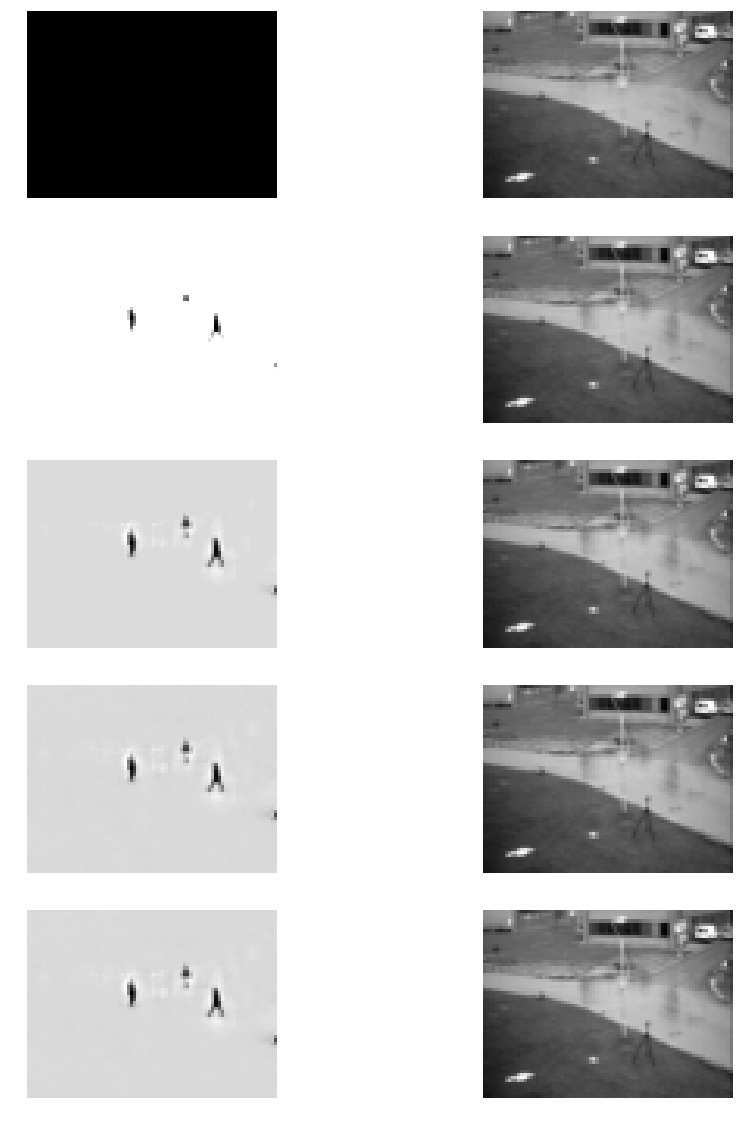

In [96]:
plots(examples, dims, rows=5)

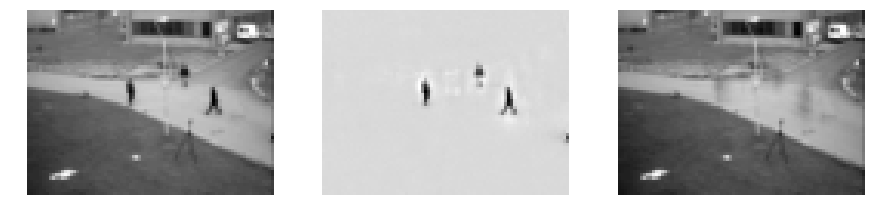

In [92]:
f = plt_images(M, S, L, [140], dims)

In [37]:
np.save("high_res_L.npy", L)
np.save("high_res_S.npy", S)

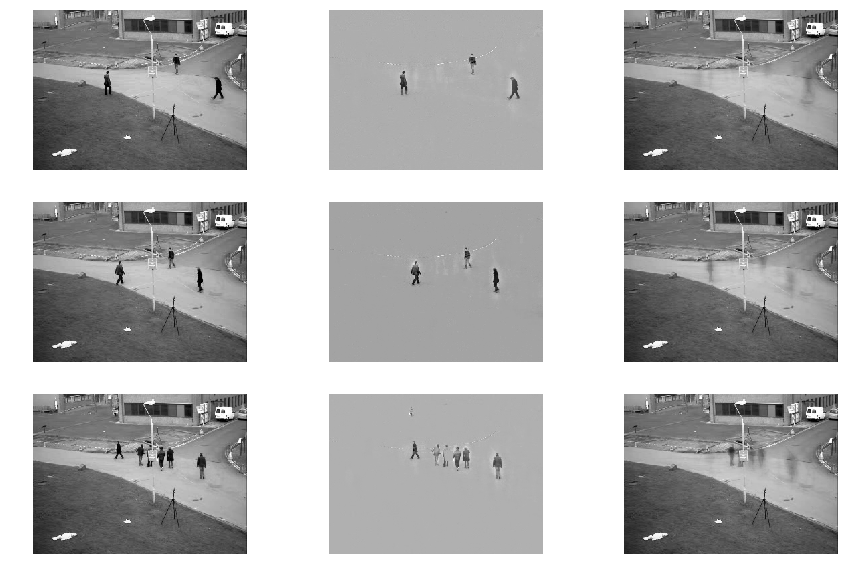

In [38]:
f = plt_images(M, S, L, [0, 100, 1000], dims)

提取一点前景（foreground）通常比识别完整背景（background）更容易。要准确得到背景，你需要移除所有前景，而不仅仅是其中一部分。

## LU 分解（LU Factorization）

无论是 `fbpca`，还是我们自己的 `randomized_range_finder` 方法，都用到了 LU 分解（LU factorization）：它把一个矩阵分解为下三角矩阵（lower triangular matrix）与上三角矩阵（upper triangular matrix）的乘积。

#### 高斯消元（Gaussian Elimination）

本节基于 Trefethen 的第 20–22 讲（lectures 20-22）。

如果你对高斯消元（Gaussian elimination）不熟悉，或需要复习，可以观看可汗学院（Khan Academy）的这个视频：[链接](https://www.khanacademy.org/math/precalculus/precalc-matrices/row-echelon-and-gaussian-elimination/v/matrices-reduced-row-echelon-form-2)。

我们手算一次高斯消元（Gaussian Elimination）来复习：

A =
 \begin{pmatrix}
  1 & -2 & -2 & -3 \\
  3 & -9 & 0 & -9 \\
  -1 & 2 & 4 & 7  \\
  -3 & -6 & 26 & 2
 \end{pmatrix}

#### 答案（Answer）：

$$ LU = \begin{bmatrix} 1 & 0 & 0 & 0\\ 3 & 1 & 0 & 0 \\ -1 & 0 & 1 & 0 \\ -3 & 4 & -2 & 1\end{bmatrix} \cdot \begin{bmatrix} 1 & -2 & -2 & -3 \\ 0 & -3 & 6 & 0 \\ 0 & 0 & 2 & 4 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$

上面的例子来自 Trefethen 的第 20、21 讲（Lectures 20, 21）。

**高斯消元（Gaussian Elimination）** 通过在左侧施加线性变换，把线性系统化为上三角形式。它本质上是在做*三角化（triangularization）*。

$ L_{m-1} \dots L_2 L_1 A = U $

$L$ 是*单位下三角（unit lower-triangular）*矩阵：对角线元素全为 1。

In [206]:
def LU(A):
 U = np.copy(A)
 m, n = A.shape
 L = np.eye(n)
 for k in range(n-1):
 for j in range(k+1,n):
 L[j,k] = U[j,k]/U[k,k]
 U[j,k:n] -= L[j,k] * U[k,k:n]
 return L, U

In [207]:
A = np.array([[2,1,1,0],[4,3,3,1],[8,7,9,5],[6,7,9,8]]).astype(np.float)

In [208]:
L, U = LU(A)

In [44]:
np.allclose(A, L @ U)

True

LU 分解很有用！

求解 $Ax=b$ 可以变成求解 $LUx=b$：
1. 分解得到 $A = LU$
2. 解 $Ly = b$
3. 再解 $Ux = y$

**计算量（Work）**

高斯消元（Gaussian Elimination）的计算量：$2\cdot\frac{1}{3} n^3$

**内存（Memory）**

上面我们构造了两个新矩阵 $L$ 和 $U$。但实际上，我们可以把 $L$ 和 $U$ 的数值直接存回矩阵 $A$ 里（覆盖掉原矩阵）。由于 $L$ 的对角线全是 1，因此无需存储对角线。像这样做**原地（in-place）**分解或计算，是数值线性代数（numerical linear algebra）里常见的节省内存技巧。注意：如果你之后还需要再次使用原矩阵 $A$，就不应该这么做。作业里有一道题就是把 LU 方法改写为原地（in-place）版本。

考虑矩阵（Consider the matrix）：$$ A = \begin{bmatrix} 10^{-20} & 1 \\ 1 & 1 \end{bmatrix} $$

In [128]:
A = np.array([[1e-20, 1], [1,1]])

手算：用高斯消元（Gaussian Elimination）求出 $L$ 和 $U$ 分别是什么：

#### 答案（Answer）

In [ ]:
#Exercise:


In [123]:
np.set_printoptions(suppress=True)

In [127]:
#Exercise:


In [129]:
L2, U2 = LU(A)

[[  1.00000000e-20 1.00000000e+00]
 [  0.00000000e+00  -1.00000000e+20]]


In [130]:
L2, U2

(array([[  1.00000000e+00, 0.00000000e+00],
 [  1.00000000e+20, 1.00000000e+00]]),
 array([[  1.00000000e-20, 1.00000000e+00],
 [  0.00000000e+00,  -1.00000000e+20]]))

In [84]:
np.allclose(L1, L2)

True

In [85]:
np.allclose(U1, U2)

True

In [86]:
np.allclose(A, L2 @ U2)

False

这就是带选主元（pivoting）的 $LU$ 分解的动机。

这也说明：LU 分解是*稳定（stable）*的，但不一定是*后向稳定（backward stable）*的。（剧透：即使使用部分选主元（partial pivoting），LU 对某些矩阵仍然会“爆炸性不稳定（explosively unstable）”，但在实践中往往表现稳定。）

#### 稳定性（Stability）

对于问题 $f$ 的算法 $\hat{f}$，如果对每个 $x$ 都有：
$$ \frac{\lVert \hat{f}(x) - f(y) \rVert}{ \lVert f(y) \rVert } = \mathcal{O}(\varepsilon_{machine}) $$

并且存在某个 $y$ 满足：
$$ \frac{\lVert y - x \rVert }{\lVert x \rVert} = \mathcal{O}(\varepsilon_{machine}) $$
那么就称 $\hat{f}$ 是**稳定（stable）**的。

**稳定的算法（stable algorithm）会对“几乎正确的问题”给出“几乎正确的答案”**（Trefethen，第 104 页）

把这句话翻译一下：
- 正确的问题（right question）：$x$
- 几乎正确的问题（nearly the right question）：$y$
- 正确的答案（right answer）：$f$
- 对“几乎正确的问题”的正确答案：$f(y)$

#### 后向稳定性（Backwards Stability）

后向稳定性（backwards stability）比稳定性（stability）**更强**也**更简洁**。

对于问题 $f$ 的算法 $\hat{f}$，如果对每个 $x$ 都有：
$$ \hat{f}(x) = f(y) $$

并且存在某个 $y$ 满足：
$$ \frac{\lVert y - x \rVert }{\lVert x \rVert} = \mathcal{O}(\varepsilon_{machine}) $$

那么就称 $\hat{f}$ 是**后向稳定（backwards stable）**的。

**后向稳定的算法会对“几乎正确的问题”给出“完全正确的答案”**（Trefethen，第 104 页）

翻译：

- 正确的问题（right question）：$x$
- 几乎正确的问题（nearly the right question）：$y$
- 正确的答案（right answer）：$f$
- 对“几乎正确的问题”的正确答案：$f(y)$

### 带部分选主元（Partial Pivoting）的 LU 分解

现在我们来看这个矩阵（Let's now look at the matrix）：$$ \hat{A} = \begin{bmatrix} 1 & 1 \\ 10^{-20} & 1 \end{bmatrix} $$

In [89]:
A = np.array([[1,1], [1e-20, 1]])

手算：用高斯消元（Gaussian Elimination）求出 $L$ 和 $U$ 分别是什么：

#### 答案（Answer）

In [ ]:
#Exercise:


In [90]:
L, U = LU(A)

In [93]:
np.allclose(A, L @ U)

True

想法（Idea）：我们可以通过交换行的顺序来获得更稳定的结果！这等价于左乘一个置换矩阵（permutation matrix）$P$。例如：

$$\begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix} \cdot \begin{bmatrix} 10^{-20} & 1 \\ 1 & 1 \end{bmatrix} =  \begin{bmatrix} 1 & 1 \\ 10^{-20} & 1 \end{bmatrix} $$

$$ PA = \hat{A} $$

然后对 $PA$ 应用高斯消元（Gaussian elimination）。

在每一步，选择第 $k$ 列中最大的元素，并把那一行换到第 $k$ 行。

#### 作业（Homework）

In [100]:
def swap(a,b):
 temp = np.copy(a)
 a[:] = b
 b[:] = temp

a=np.array([1,2,3])
b=np.array([3,2,1])
swap(a,b)
a,b

In [102]:
#Exercise: re-write the LU factorization above to use pivoting


#### 例子（Example）

In [104]:
A = np.array([[2,1,1,0],[4,3,3,1],[8,7,9,5],[6,7,9,8]]).astype(np.float)

In [105]:
L, U, P = LU_pivot(A)

你可以把下面的结果与 Trefethen（第 159 页）的答案对照：

In [106]:
A

array([[ 2.,  1.,  1.,  0.],
 [ 4.,  3.,  3.,  1.],
 [ 8.,  7.,  9.,  5.],
 [ 6.,  7.,  9.,  8.]])

In [107]:
U

array([[ 8. ,  7. ,  9. ,  5. ],
 [ 0. ,  1.75 ,  2.25 ,  4.25 ],
 [ 0. ,  0. , -0.28571429,  0.57142857],
 [ 0. ,  0. ,  0. , -2. ]])

In [114]:
P

array([[ 0.,  0.,  1.,  0.],
 [ 0.,  0.,  0.,  1.],
 [ 1.,  0.,  0.,  0.],
 [ 0.,  1.,  0.,  0.]])

**部分选主元（Partial pivoting）**会对行进行置换（permutes the rows）。这是一种非常普遍的做法，所以很多时候提到 *LU 分解（LU factorization）*，默认指的就是带部分选主元的版本。

**完全选主元（Complete pivoting）**会同时对行和列进行置换。完全选主元的时间开销明显更大，因此在实践中很少使用。

#### 例子（Example）

考虑下面这个方程组（system of equations）：

$$ \begin{bmatrix} 1 & 0 & 0  & 0 & 0 & 1 \\ -1 & 1 & 0  & 0 & 0 & 1 \\ -1 & -1 & 1  & 0 & 0 & 1 \\ -1 & -1 & -1  & 1 & 0 & 1  \\  -1 & -1 & -1  & -1 & 1 & 1 \\ -1 & -1 & -1  & -1 & -1 & 1 \end{bmatrix} \mathbf{x} = \begin{bmatrix} 1 \\ 1 \\ 1  \\ 1 \\ 2 \\ 1 \end{bmatrix} $$

In [99]:
def make_matrix(n):
 A = np.eye(n)
 for i in range(n):
 A[i,-1] = 1
 for j in range(i):
 A[i,j] = -1
 return A 

In [117]:
def make_vector(n):
 b = np.ones(n)
 b[-2] = 2
 return b

In [101]:
make_vector(7)

array([ 1.,  1.,  1.,  1.,  1.,  2.,  1.])

#### 练习（Exercise）

练习（Exercise）：我们对这个 $5 \times 5$ 的系统做高斯消元（Gaussian Elimination）。

SciPy（Scipy）也提供了相应功能。我们来看看当 $n=10,\,20,\,30,\,40,\,50,\,60$ 时，最后 5 个方程（entries）的解是什么样子。

In [131]:
?scipy.linalg.solve

[-0.00195312 -0.00390625 -0.0078125  -0.015625 -0.03125 -0.0625 -0.125
 -0.25 0.5 1.00195312]
[ -1.90734863e-06  -3.81469727e-06  -7.62939453e-06  -1.52587891e-05
  -3.05175781e-05  -6.10351562e-05  -1.22070312e-04  -2.44140625e-04
  -4.88281250e-04  -9.76562500e-04  -1.95312500e-03  -3.90625000e-03
  -7.81250000e-03  -1.56250000e-02  -3.12500000e-02  -6.25000000e-02
  -1.25000000e-01  -2.50000000e-01 5.00000000e-01 1.00000191e+00]
[ -1.86264515e-09  -3.72529030e-09  -7.45058060e-09  -1.49011612e-08
  -2.98023224e-08  -5.96046448e-08  -1.19209290e-07  -2.38418579e-07
  -4.76837158e-07  -9.53674316e-07  -1.90734863e-06  -3.81469727e-06
  -7.62939453e-06  -1.52587891e-05  -3.05175781e-05  -6.10351562e-05
  -1.22070312e-04  -2.44140625e-04  -4.88281250e-04  -9.76562500e-04
  -1.95312500e-03  -3.90625000e-03  -7.81250000e-03  -1.56250000e-02
  -3.12500000e-02  -6.25000000e-02  -1.25000000e-01  -2.50000000e-01
 5.00000000e-01 1.00000000e+00]
[ -1.81898940e-12  -3.63797881e-12  -7.27595761e-

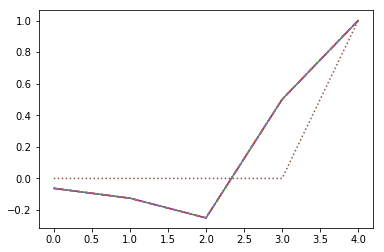

In [112]:
for n, ls in zip(range(10, 70, 10), ['--', ':', '-', '-.', '--', ':']):
 soln = scipy.linalg.lu_solve(scipy.linalg.lu_factor(make_matrix(n)), make_vector(n))
 plt.plot(soln[-5:], ls)
 print(soln)

当 $n=60$ 时发生了什么？

**定理（Theorem）**：设矩阵 $A$ 的分解 $PA = LU$ 由带部分选主元（partial pivoting）的高斯消元（Gaussian Elimination）计算得到。则计算机（采用浮点运算，Floating Point Arithmetic）实际算出来的矩阵 $\hat{P}$、$\hat{L}$、$\hat{U}$ 满足：

$$\hat{L}\hat{U} = \hat{P} A + \delta A, \quad \frac{\delta A}{A} = \mathcal{O}(\rho \varepsilon_{machine}) $$

其中 $\rho$ 是*增长因子（growth factor）*：

$$\rho = \frac{max_{i,j} \lvert u_{ij} \rvert }{max_{i,j} \lvert a_{ij} \rvert } $$

对上面的矩阵而言，$\rho = 2^{m-1}$。

#### 理论上不稳定，但实践中稳定（Unstable in theory, stable in practice）

大多数算法（例如 QR）的稳定性（stability）相对直接；但带部分选主元（partial pivoting）的高斯消元（Gaussian Elimination）就没那么简单。高斯消元（无论是否选主元）只有在 $L$ 和/或 $U$ 相对 $A$ 的规模变得很大时，才会出现不稳定（instability）。

Trefethen："尽管存在像 (22.4) 这样的例子，带部分选主元的高斯消元在实践中仍然是完全稳定的……在五十年的计算历史中，还没有已知的、在自然情形下出现的矩阵问题会触发爆炸性不稳定（explosive instability）。"（当然，人为构造一些反例（contrived examples）很容易。）

尽管某些矩阵会导致不稳定，但这类矩阵在所有矩阵中占比极小，因此出于统计原因几乎“不会”在实践中出现。"如果你随机挑选十亿个矩阵，你几乎肯定找不到一个会让高斯消元不稳定的矩阵。"

### 延伸阅读（Further Reading）
- 高斯消元（Gaussian Elimination）/LU 分解（LU factorization）——Trefethen 第 20 讲
- 选主元（Pivoting）——Trefethen 第 21 讲
- 高斯消元的稳定性（Stability of Gaussian Elimination）——Trefethen 第 22 讲

## 上节课的补充（Follow up from last class）

### 随机投影（Randomized Projections）到底在做什么？

我们在对下面矩阵的各列做线性组合（linear combination），并且组合系数是随机权重（random weights）：

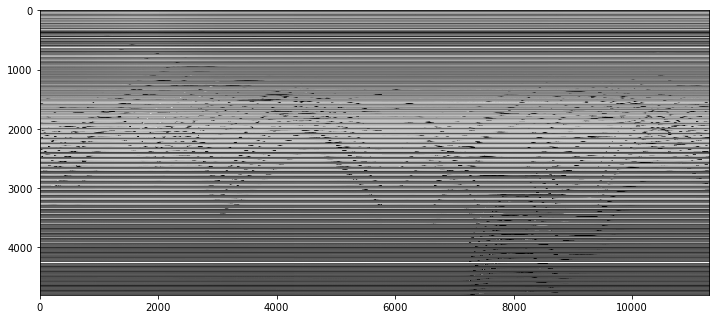

In [33]:
plt.figure(figsize=(12, 12))
plt.imshow(M, cmap='gray')

这有点像随机加权平均（random weighted average）。如果你做若干次这样的组合，最终会得到彼此正交归一（orthonormal）的列向量。

**约翰逊–林登施特劳斯引理（Johnson–Lindenstrauss Lemma）**（[来自维基百科（from wikipedia）](https://en.wikipedia.org/wiki/Johnson%E2%80%93Lindenstrauss_lemma)）：高维空间中的一小组点，可以被嵌入到一个低得多的维度空间中，同时尽可能保持点与点之间的距离（distances）几乎不变。

我们希望能够在降维（reduce dimensionality）时尽量保留数据的关键结构（relevant structure）。Johnson–Lindenstrauss 引理就是这类结果中的经典定理（classic result）。

### 高斯消元的历史（History of Gaussian Elimination）

[关于高斯消元的迷人历史（Fascinating history of Gaussian Elimination）](https://jvns.ca/blog/2017/04/16/making-small-culture-changes/)。一些要点：

- 最早关于高斯消元的文字记录大约出现在公元前 200 年左右，来自中国古籍《九章算术（Nine Chapters on Arithmetic）》
- 古代中国人使用彩色算筹（colored bamboo rods），按列摆放在“算板（counting board）”上进行计算
- 日本数学家关孝和（Seki Kowa，1642–1708）继承并发展了中国的消元方法，并在 1683 年之前发明了行列式（determinant）。大约同一时期，莱布尼茨（Leibniz）也独立得到了类似发现，但关孝和和莱布尼茨都没有因这些发现得到应有的认可（credit）。
- 高斯（Gauss）把这种消元方法称为“众所周知（commonly known）”，从未声称是自己发明的；不过他可能发明了 Cholesky 分解（Cholesky decomposition）

[更多历史见这里（More history here）](http://www.sciencedirect.com/science/article/pii/S0315086010000376)

### 加速高斯消元（Speeding Up Gaussian Elimination）

[并行化 LU 分解（Parallelized LU Decomposition）](https://courses.engr.illinois.edu/cs554/fa2013/notes/06_lu_8up.pdf)：LU 分解可以做到完全并行化（fully parallelized）。

[随机化 LU 分解（Randomized LU Decomposition）](http://www.sciencedirect.com/science/article/pii/S1063520316300069)（2016 年论文）：随机化 LU 在标准 GPU 显卡上实现为完整流程运行，并且无需 GPU–CPU 之间的数据传输（data transfer）。

### `scipy.linalg.solve` 与 `lu_solve` 的对比（Scipy.linalg solve vs lu_solve）

In [142]:
n = 100
A = make_matrix(n)
b = make_vector(n)

这个问题有很大的*增长因子（growth factor）*：$= 2^{59}$。使用 `scipy.linalg.lu_solve` 会得到错误答案，但用 `scipy.linalg.solve` 会得到正确答案。`scipy.linalg.solve` 做了什么不同的事情？

In [143]:
print(scipy.linalg.lu_solve(scipy.linalg.lu_factor(A), b)[-5:])
print(scipy.linalg.solve(A, b)[-5:])

[ 0.  0.  0.  0.  1.]
[-0.0625 -0.125  -0.25 0.5 1. ]


In [136]:
%%timeit
soln = scipy.linalg.lu_solve(scipy.linalg.lu_factor(A), b)
soln[-5:]

91.2 µs ± 192 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [137]:
%%timeit
soln = scipy.linalg.solve(A, b)
soln[-5:]

153 µs ± 5 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


查看 [scipy 的源码（source code）](https://github.com/scipy/scipy/blob/v0.19.0/scipy/linalg/basic.py#L25-L224) 可以发现它调用了 LAPACK 例程（routine）`gesvx`。这里是 [sgesvx 的 Fortran 源码（Fortran source code）](http://www.netlib.org/lapack/explore-html/d0/db8/group__real_g_esolve_ga982d53a8a62d66af9bcaa50642c95ea4.html#ga982d53a8a62d66af9bcaa50642c95ea4)（`s` 代表单精度（single）；另外还有用于双精度（doubles）的 `dgesvx` 以及用于复数（complex numbers）的 `cgesvx`）。在注释（comments）里可以看到，它会计算*主元增长因子的倒数（reciprocal pivot growth factor）*，因此它会把这个增长因子考虑进去，执行比“朴素的带部分选主元 LU 分解（plain partial pivot LU factorization）”更复杂的处理。

## 块矩阵（Block Matrices）

这是对上一节课里关于块矩阵（block matrices）问题的一个补充。不过在此之前，先看：

### 普通矩阵乘法（Ordinary Matrix Multiplication）

**问题（Question）**：对两个 $n \times n$ 矩阵做乘法 $A \times B = C$，其计算复杂度（大 $\mathcal{O}$，big $\mathcal{O}$）是多少？

你可以在 [Codecademy](https://www.codecademy.com/courses/big-o/0/1) 学习（或复习）大 $\mathcal{O}$。

它的伪代码大致是这样：

 for i=1 to n
 {把 A 的第 i 行读入快速内存（fast memory）}
 for j=1 to n
 {把 B 的第 j 列读入快速内存（fast memory）}
 for k=1 to n
 C[i,j] = C[i,j] + A[i,k] x B[k,j]
 {把 C[i,j] 写回慢速内存（slow memory）}
 
**问题（Question）**：一共发生了多少次读（reads）和写（writes）？

### 块矩阵乘法（Block Matrix Multiplication）

把 $A,\, B,\, C$ 划分成 $N\times N$ 个块（blocks），每个块的大小是 $\frac{n}{N} \times \frac{n}{N}$。

 <img src="images/block_matrix.png" alt="Block Matrix" style="width: 80%"/>
  （[来源（Source）](http://avishek.net/blog/?p=804)）

它的伪代码大致是这样：

 for i=1 to N
 for j=1 to N
 for k=1 to N
 {读取 A 的块 (i,k)}
 {读取 B 的块 (k,j)}
 C 的块 (i,j) += A 的块 乘以 B 的块
 {把 C 的块 (i,j) 写回慢速内存（slow memory）}
 
**问题 1（Question 1）**：它的 big-$\mathcal{O}$ 是多少？

**问题 2（Question 2）**：一共发生了多少次读（reads）和写（writes）？

# 结束（End）